# Gráficas de sensibilidad: influencia de T y E
Requiere `resultados_agregados_TPE.csv` y `resultados_detalle_TPE.csv` en el mismo directorio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('resultados_agregados_TPE.csv')
df_det = pd.read_csv('resultados_detalle_TPE.csv')

In [2]:
df

,T,E,logloss_perdido_medio,logloss_perdido_std,iter_ahorradas_media,iter_ahorradas_std,n_datasets
0,5,-0.2,2.8906,3.2790,70.1178,28.8074,20
1,5,-0.1,2.3017,2.3037,67.6244,29.5160,20
2,5,0.0,1.6944,2.1298,59.8518,31.4695,20
3,5,0.1,0.4705,1.0376,39.1095,32.5150,20
4,10,-0.2,3.1964,4.1325,69.5597,28.5661,20
5,10,-0.1,2.6256,4.2974,66.4699,28.6398,20
6,10,0.0,1.6781,3.3923,57.9764,28.9040,20
7,10,0.1,0.5877,1.3405,36.6863,30.7074,20
8,15,-0.2,3.0564,4.3060,67.2828,28.5119,20
9,15,-0.1,2.6672,4.3983,64.4677,28.4708,20


In [3]:
df_det

,T,E,fold_cv,task_id,logloss_poda,logloss_real,logloss_perdido(%),n_iter_poda,n_iter_real,iter_ahorradas(%),sesgo_calibracion
0,5,-0.2,0,146820,0.039400,0.037995,3.6979,107319,1238041,91.3315,-0.081184
1,5,-0.2,0,168350,0.227085,0.225671,0.6266,210060,630490,66.6831,-0.070451
2,5,-0.2,0,190392,0.359271,0.317200,13.2632,111520,713336,84.3664,0.093678
3,5,-0.2,0,359956,0.287348,0.285494,0.6494,113588,441191,74.2542,-0.024419
4,5,-0.2,0,359965,0.016131,0.016131,0.0000,795605,849323,6.3248,-0.124352
...,...,...,...,...,...,...,...,...,...,...,...
315,20,0.1,2,190410,0.439612,0.425278,3.3705,212764,545157,60.9720,0.096177
316,20,0.1,2,190411,0.290798,0.290798,0.0000,663006,1027795,35.4924,0.022963
317,20,0.1,2,359962,0.307655,0.307655,0.0000,153697,200627,23.3917,0.036846
318,20,0.1,2,359968,0.140843,0.140843,0.0000,227853,817466,72.1269,-0.027531


### Configuración de estilo global

In [4]:
COLOR_E = {
    -0.2: '#A32D2D',
    -0.1: '#F08080',  
     0.0: '#1D9E75',
     0.1: '#085041',
}

MARKER_T = {
     5: 'o',
    10: 's',
    15: '^',
    20: 'D',
}

LABEL_E = {
    -0.2: 'E = −0.2   (agresiva)',
    -0.1: 'E = −0.1',
     0.0: 'E = 0',
     0.1: 'E = 0.1     (conservadora)',
}

T_vals = [5, 10, 15, 20]
E_vals = [-0.2, -0.1, 0.0, 0.1]

## Gráfica 1: Compromiso ahorro-degradación

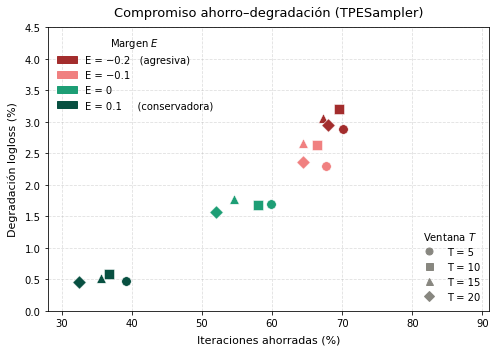

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for _, row in df.iterrows():
    T = int(row['T'])
    E = round(float(row['E']), 1)
    ax.scatter(
        row['iter_ahorradas_media'],
        row['logloss_perdido_medio'],
        color=COLOR_E[E],
        marker=MARKER_T[T],
        s=90,
        zorder=3,
        linewidths=0.5,
        edgecolors='white',
    )

# Leyenda de colores (E)
legend_E = [
    mpatches.Patch(color=COLOR_E[e], label=LABEL_E[e])
    for e in E_vals
]

# Leyenda de marcadores (T)
legend_T = [
    plt.Line2D([0], [0], marker=MARKER_T[t], color='#888780',
               linestyle='None', markersize=7, label=f'T = {t}')
    for t in T_vals
]

leg1 = ax.legend(handles=legend_E, title='Margen $E$', loc='upper left',
                 frameon=False, title_fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=legend_T, title='Ventana $T$', loc='lower right',
          frameon=False, title_fontsize=10)

ax.set_xlabel('Iteraciones ahorradas (%)', fontsize=11, labelpad=7)
ax.set_ylabel('Degradación logloss (%)', fontsize=11, labelpad=7)
ax.set_title('Compromiso ahorro–degradación (TPESampler)', fontsize=13, pad=11)  
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(28, 91)
ax.set_ylim(0, 4.5)

plt.tight_layout()
#plt.savefig('scatter_TPE.png', bbox_inches='tight', facecolor='white', dpi=230)
plt.show()

## Gráfica 2: Efecto de E fijando T

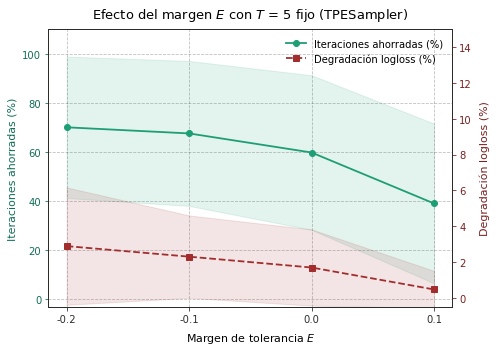

In [6]:
T_FIJO = 5
sub = df[df['T'] == T_FIJO].sort_values('E')

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#2C2C2A')
        spine.set_linewidth(1.0)

x = sub['E'].values

ax1.plot(x, sub['iter_ahorradas_media'], color='#1D9E75', marker='o',
         linewidth=1.8, markersize=6, label='Iteraciones ahorradas (%)')
ax1.fill_between(
    x,
    sub['iter_ahorradas_media'] - sub['iter_ahorradas_std'],
    sub['iter_ahorradas_media'] + sub['iter_ahorradas_std'],
    color='#1D9E75', alpha=0.12
)

ax2.plot(x, sub['logloss_perdido_medio'], color='#A32D2D', marker='s',
         linewidth=1.8, markersize=6, linestyle='--', label='Degradación logloss (%)')
ax2.fill_between(
    x,
    sub['logloss_perdido_medio'] - sub['logloss_perdido_std'],
    sub['logloss_perdido_medio'] + sub['logloss_perdido_std'],
    color='#A32D2D', alpha=0.12
)

ax1.set_xlabel('Margen de tolerancia $E$', labelpad=7, fontsize=11)
ax1.set_ylabel('Iteraciones ahorradas (%)', color='#0F6E56', labelpad=5, fontsize=11)
ax2.set_ylabel('Degradación logloss (%)', color='#791F1F', labelpad=7, fontsize=11)

ax1.tick_params(axis='y', colors='#0F6E56')
ax2.tick_params(axis='y', colors='#791F1F')
ax1.tick_params(axis='x', colors='#2C2C2A')

ax1.set_xticks(E_vals)
ax1.set_xticklabels([str(e) for e in E_vals], fontsize=10)

ax1.set_title(f'Efecto del margen $E$ con $T$ = {T_FIJO} fijo (TPESampler)',
              pad=11, fontsize=13)

ax1.grid(True, linestyle='--', alpha=0.3, color='#2C2C2A')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=10)

ax1.set_ylim(-3, 110)
ax2.set_ylim(-0.5, 15)

plt.tight_layout()
#plt.savefig(f'efectoE_TPE.png', bbox_inches='tight', facecolor='white', dpi=230)
plt.show()